In [ ]:
!pip install torch torchvision timm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/ODIR-5K.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/ODIR-5K/Training Images/2457_left.jpg  
  inflating: /content/ODIR-5K/Training Images/2457_right.jpg  
  inflating: /content/ODIR-5K/Training Images/2458_left.jpg  
  inflating: /content/ODIR-5K/Training Images/2458_right.jpg  
  inflating: /content/ODIR-5K/Training Images/2459_left.jpg  
  inflating: /content/ODIR-5K/Training Images/2459_right.jpg  
  inflating: /content/ODIR-5K/Training Images/245_left.jpg  
  inflating: /content/ODIR-5K/Training Images/245_right.jpg  
  inflating: /content/ODIR-5K/Training Images/2460_left.jpg  
  inflating: /content/ODIR-5K/Training Images/2460_right.jpg  
  inflating: /content/ODIR-5K/Training Images/2461_left.jpg  
  inflating: /content/ODIR-5K/Training Images/2461_right.jpg  
  inflating: /content/ODIR-5K/Training Images/2462_left.jpg  
  inflating: /content/ODIR-5K/Training Images/2462_right.jpg  
  inflating: /content/ODIR-5K/Training Images/2463_left.jpg  
  inflating: /

In [ ]:
import os

base_path = "/content/ODIR-5K"

train_path = os.path.join(base_path, "Training Images")
test_path = os.path.join(base_path, "Testing Images")
excel_path = os.path.join(base_path, "data.xlsx")

print("Paths set!")

Paths set!


In [ ]:
import pandas as pd

df = pd.read_excel(excel_path)
print("Data loaded!")

Data loaded!


In [ ]:
print(df.columns)

Index(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus',
       'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G',
       'C', 'A', 'H', 'M', 'O'],
      dtype='object')


In [ ]:
import os

output_path = "/content/dataset"

cataract_path = os.path.join(output_path, "cataract")
normal_path = os.path.join(output_path, "normal")

os.makedirs(cataract_path, exist_ok=True)
os.makedirs(normal_path, exist_ok=True)

print("Folders ready!")

Folders ready!


In [ ]:
# Loop through data
import shutil
for index, row in df.iterrows():

    filenames = [row['Left-Fundus'], row['Right-Fundus']]

    for filename in filenames:
        if pd.notna(filename):  # make sure filename exists

            src = os.path.join(train_path, filename)

            if os.path.exists(src):

                if row['C'] == 1:  # Cataract
                    shutil.copy(src, cataract_path)

                elif row['N'] == 1:  # Normal
                    shutil.copy(src, normal_path)

In [ ]:
import shutil
DATA_PATH = "/content/dataset"

In [ ]:
import os
print(os.listdir(DATA_PATH))

['cataract', 'normal']


In [ ]:
!pip install torch torchvision timm

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoch 1, Loss: 52.9436
Epoch 2, Loss: 50.0710
Epoch 3, Loss: 49.2092
Epoch 4, Loss: 48.4760
Epoch 5, Loss: 47.7590


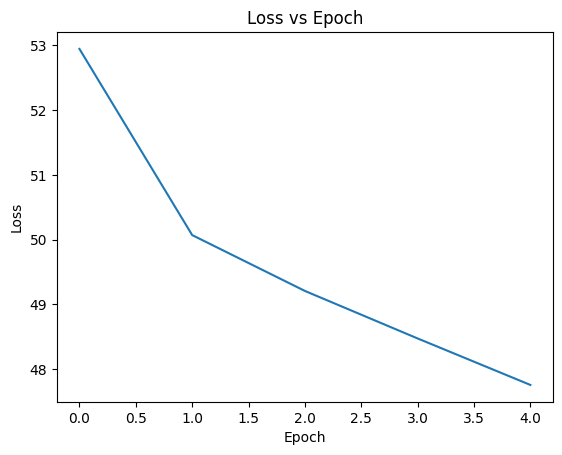

Accuracy: 97.52%
Accuracy: 97.52%
Precision: 0.98
Recall: 0.99


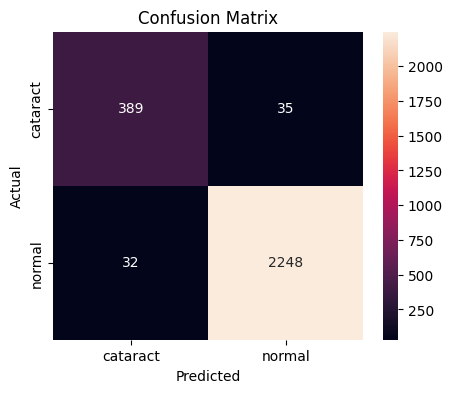

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
from PIL import Image

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# =====================
# DATA
# =====================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(DATA_PATH, transform=transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

num_classes = len(dataset.classes)

# =====================
# TEACHER MODEL (ViT)
# =====================
teacher = timm.create_model('vit_base_patch16_224', pretrained=True)
teacher.head = nn.Linear(teacher.head.in_features, num_classes)
teacher = teacher.to(device)

# =====================
# STUDENT MODEL (ResNet18)
# =====================
student = timm.create_model('resnet18', pretrained=True)
student.fc = nn.Linear(student.fc.in_features, num_classes)
student = student.to(device)

# =====================
# LOSS + OPTIMIZER
# =====================
criterion = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer = optim.Adam(student.parameters(), lr=1e-4)

# =====================
# TRAIN FUNCTION
# =====================
def train(student, teacher, loader, epochs=5, T=3, alpha=0.5):

    teacher.eval()
    losses = []

    for epoch in range(epochs):
        student.train()
        total_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                teacher_out = teacher(images)

            student_out = student(images)

            loss_ce = criterion(student_out, labels)

            soft_teacher = torch.softmax(teacher_out / T, dim=1)
            soft_student = torch.log_softmax(student_out / T, dim=1)

            loss_kd = kl_loss(soft_student, soft_teacher) * (T*T)

            loss = alpha * loss_ce + (1-alpha) * loss_kd

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    # Plot loss graph
    plt.plot(losses)
    plt.title("Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

# =====================
# EVALUATION (Basic)
# =====================
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuracy: {accuracy:.2f}%")

# =====================
# ADVANCED METRICS
# =====================
def evaluate_metrics(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)

    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision: {prec:.2f}")
    print(f"Recall: {rec:.2f}")

# =====================
# CONFUSION MATRIX
# =====================
def plot_confusion_matrix(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=dataset.classes,
                yticklabels=dataset.classes)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# =====================
# PREDICTION FUNCTION
# =====================
def predict_image(model, image_path):
    model.eval()

    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

    class_name = dataset.classes[pred.item()]

    plt.imshow(img)
    plt.title(f"Prediction: {class_name}")
    plt.axis('off')
    plt.show()

    print("Prediction:", class_name)

# =====================
# RUN EVERYTHING
# =====================
train(student, teacher, loader)

evaluate(student, loader)
evaluate_metrics(student, loader)
plot_confusion_matrix(student, loader)

In [ ]:
-evaluate(student, loader)

Accuracy: 98.34%


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1355_right.jpg to 1355_right.jpg


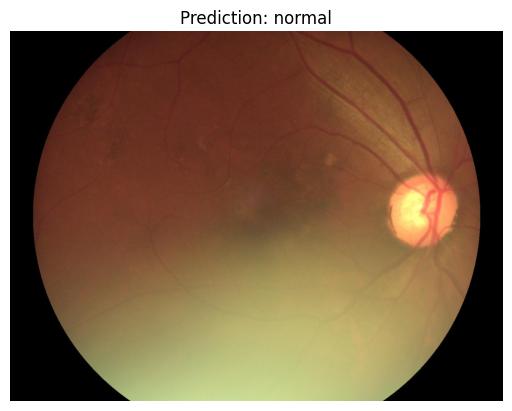

Prediction: normal


In [ ]:
image_path = list(uploaded.keys())[0]
predict_image(student, image_path)